In [8]:
import numpy as np
import pandas as pd

from bs4 import BeautifulSoup
import re

import matplotlib.pyplot as plt
%matplotlib inline

In [24]:
# this data was obtained as an xml file from the Bureau of Labor Statistics 
# https://www.bls.gov/ooh/about/ooh-developer-info.htm

data = pd.read_csv("~/Documents/Data_Science_Projects/Occupation_Handbook/occupation_compilation.csv")

In [25]:
data.head()

,/current_year,/current_year/#agg,/last_updated,/occupation/#id,/occupation/citation,/occupation/description/@type,/occupation/description,/occupation/how_to_become_one/section_body/@type,/occupation/how_to_become_one/section_body,/occupation/how_to_become_one/section_image/@type,...,/occupation/work_environment/section_image/@type,/occupation/work_environment/section_image,/occupation/work_environment/section_title/@type,/occupation/work_environment/section_title,/projection_year,/projection_year/#agg,/publication_title,/reference_period,/reference_year,/reference_year/#agg
0,2023,2023.0,1/17/2025,1,\n\t\t\t\n\t\t<!-- BLS CITATION -->\n ...,text,Accountants and auditors prepare and examine f...,html,\n\t\t\t\t\n<p>Accountants and auditors typic...,html,...,html,"\n\t\t\t\n\t\t\t\n\t<img src=""/ooh/images/1741...",text,Work Environment,2033,2033.0,Occupational Outlook Handbook,May 2023,2023,2023.0
1,2023,NaN,1/17/2025,2,\n\t\t\t\n\t\t<!-- BLS CITATION -->\n ...,text,Actors express ideas and portray characters in...,html,\n\t\t\t\t\n<p>Actors typically enhance their...,html,...,html,"\n\t\t\t\n\t\t\t\n\t<img src=""/ooh/images/2286...",text,Work Environment,2033,NaN,Occupational Outlook Handbook,May 2023,2023,NaN
2,2023,NaN,1/17/2025,3,\n\t\t\t\n\t\t<!-- BLS CITATION -->\n ...,text,"Actuaries use mathematics, statistics, and fin...",html,"\n\t\t\t\t\n<p>To enter the occupation, actua...",html,...,html,"\n\t\t\t\n\t\t\t\n\t<img src=""/ooh/images/1829...",text,Work Environment,2033,NaN,Occupational Outlook Handbook,May 2023,2023,NaN
3,2023,NaN,1/17/2025,4,\n\t\t\t\n\t\t<!-- BLS CITATION -->\n ...,text,Administrative services and facilities manager...,html,\n\t\t\t\t\n<p>Educational requirements for a...,html,...,html,"\n\t\t\t\n\t\t\t\n\t<img src=""/ooh/images/1590...",text,Work Environment,2033,NaN,Occupational Outlook Handbook,May 2023,2023,NaN
4,2023,NaN,1/17/2025,4,\n\t\t\t\n\t\t<!-- BLS CITATION -->\n ...,text,Administrative services and facilities manager...,html,\n\t\t\t\t\n<p>Educational requirements for a...,html,...,html,"\n\t\t\t\n\t\t\t\n\t<img src=""/ooh/images/1590...",text,Work Environment,2033,NaN,Occupational Outlook Handbook,May 2023,2023,NaN


In [14]:
"""#make row 1 the heading row
data.columns = list(data.iloc[0,:])
data = data.iloc[1:]
data.head(3)"""

'#make row 1 the heading row\ndata.columns = list(data.iloc[0,:])\ndata = data.iloc[1:]\ndata.head(3)'

### Steps Taken

* formatting to get column names in header
* reduce dimensionality by getting rid of columns with certain string patterns
* scan data for columns of interest for my task
* started cleaning data within columns of interest to prep for word2vec
* built embedding models and plotted and observed similar word outputs. Iterated on what columns to include in training. test and iterate
    * tried not to put columns that had redundant info
    * had to go back and parse columns better to get rid of noise
    * removed sentences/phrases that appeared in all rows of the dataset

In [26]:
bad_str_lst = ['@type','#agg', 'citation', 'state_and_area']

columns_to_drop = [col for col in data.columns if any(string in col for string in bad_str_lst)]
data = data.drop(columns=columns_to_drop)

In [28]:
len(data)

598

In [17]:
pd.set_option('display.max_colwidth', None)
pd.reset_option('display.max_colwidth')

* any column with @type, delete it
* any column with #agg, delete it
* '<p>', '</p>',
* or instead of taking out tags, only keep strings that start with > and end with<
* extract wage as a numeric feature. May add something to amazing race

use beautiful soup to parse out the text in the columns?

columns of interest:
'/occupation/occupation_name_short_singular',
'/occupation/summary_pay', '/occupation/quick_facts/qf_median_pay_annual/range', '/occupation/quick_facts/qf_median_pay_annual/value',
'/occupation/summary_what_they_do', '/occupation/what_they_do/section_body', '/occupation/summary_work_environment', '/occupation/what_they_do/section_body', '/occupation/work_environment/section_body', 
'/occupation/description', '/occupation/how_to_become_one/section_body',
'/occupation/quick_facts/qf_entry_level_education/value',
'/occupation/similar_occupations/section_body'

In [18]:
# Select columns of interest and clean up dataframe
dat = data [['/occupation/occupation_name_short_singular',
'/occupation/quick_facts/qf_median_pay_annual/value', '/occupation/description',
             '/occupation/quick_facts/qf_entry_level_education/value',
'/occupation/summary_what_they_do', '/occupation/what_they_do/section_body', '/occupation/summary_work_environment', '/occupation/what_they_do/section_body', '/occupation/work_environment/section_body', 
 '/occupation/how_to_become_one/section_body',
'/occupation/similar_occupations/section_body']]

dat.drop_duplicates(inplace=True)
dat = dat.reset_index(drop=True)
dat.fillna("", inplace=True)

/opt/anaconda3/envs/ls_geo_env/lib/python3.7/site-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [19]:
#dat.iloc[214:,:]#dat[dat['/occupation/occupation_name_short_singular'] == "Middle School Teacher"]

In [20]:
def getmy_text(html):
    # Parse the HTML
    soup = BeautifulSoup(html, 'html.parser')
    
    try:

        # Extract text inside the <p> tag
        p_text = soup.find('p').get_text()
    except:
        p_text=""
    
    try:
        
        h4_text = soup.find('h4').get_text()
    except:
        h4_text=""
    try:
        
        li_text = soup.find('li').get_text()
    except:
        li_text=""
    try:
        
        em_text = soup.find('em').get_text()
    except:
        em_text=""
    try:
        # Find the tbody
        tbody = soup.find('tbody')

        # Extract all <p> tags within the tbody
        p_tags = tbody.find_all('p')

        # Get the text from each <p> tag
        p_texts = [p.get_text(strip=True) for p in p_tags]
        txt = " ".join(p_texts)
        txt = txt.replace('\xa0', ' ')
    except:
        txt=""
    
    

    return p_text + " " + h4_text + " " + li_text + " " + em_text + " " + txt

dic = {}
for n in range(4,11):
    print(n)
    col = dat.iloc[:,n]
    
    
    dic[col.name]= [ getmy_text(i) for i in col]
    

4
5
6
7
8
9
10


In [21]:


z = dat.iloc[0,10]
soup = BeautifulSoup(z, 'html.parser')
"""txt = soup.find('tbody').get_text()
txt=txt.replace('\n', ' ').strip()
txt = txt.replace('\xa0', ' ')
#alpha_chars = [char for char in txt if char.isalpha() | char == " "]
#"".join(alpha_chars)
txt =txt.replace('  ', '')
txt = re.sub(r'[^a-zA-Z\s]', '', txt)
txt
"""
# Find the tbody
tbody = soup.find('tbody')

# Extract all <p> tags within the tbody
p_tags = tbody.find_all('p')

# Get the text from each <p> tag
p_texts = [p.get_text(strip=True) for p in p_tags]
txt = " ".join(p_texts)
txt = txt.replace('\xa0', ' ')
txt

'Bookkeeping, accounting, and auditing clerks compute, classify, and record data to help organizations keep complete and accurate financial records. Budget analysts help public and private organizations plan their finances. Cost estimators collect and analyze data in order to assess the time, money, materials, and labor required to make a product or provide a service. Financial analysts guide businesses and individuals in decisions about expending money to attain profit. Financial managers create financial reports, direct investment activities, and develop plans for the long-term financial goals of their organization. Management analysts recommend ways to improve an organization’s efficiency. Personal financial advisors provide advice to help individuals manage their money and plan for their financial future. Postsecondary teachers instruct students in a variety of academic subjects beyond the high school level. Tax examiners and collectors, and revenue agents determine how much is owe

In [22]:
df = pd.concat([dat.iloc[:,0:4], pd.DataFrame(dic)], axis=1)

# there are some redundancies in column content, so narrow down
df = df[['/occupation/occupation_name_short_singular', '/occupation/quick_facts/qf_median_pay_annual/value', 
    '/occupation/what_they_do/section_body', '/occupation/how_to_become_one/section_body', 
    '/occupation/summary_work_environment' , '/occupation/similar_occupations/section_body'
]]

df['/occupation/summary_work_environment'] = [i.replace("Work Environment", "").strip() for i in df['/occupation/summary_work_environment'] ]

df['/occupation/similar_occupations/section_body'] = [i.replace("This table shows a list of occupations with job duties that are similar to those of ","").strip() for i in df['/occupation/similar_occupations/section_body']]

txt = df['/occupation/what_they_do/section_body'] + df['/occupation/how_to_become_one/section_body'] + df['/occupation/summary_work_environment'] #+ df['/occupation/similar_occupations/section_body']



In [23]:
df.to_csv("~/Documents/Data_Science_Projects/Amazing_Race/000_AmazingRaceAnalysis_and_Modeling/OOH_clean.csv", header=True)


In [327]:
df.head()

,/occupation/occupation_name_short_singular,/occupation/quick_facts/qf_median_pay_annual/value,/occupation/what_they_do/section_body,/occupation/how_to_become_one/section_body,/occupation/summary_work_environment,/occupation/similar_occupations/section_body
0,Accountant or Auditor,79880,"Accountants and auditors prepare and examine financial records, identify potential areas of opportunity and risk, and provide solutions for businesses and individuals. They ensure that financial records are accurate, that financial and data risks are evaluated, and that taxes are paid properly. They also assess financial operations and work to help ensure that organizations run efficiently. Examine financial statements to ensure that they are accurate and comply with laws and regulations Government accountants","Accountants and auditors typically need at least a bachelor’s degree in accounting or a related field to enter the occupation. Completing certification in a specific field of accounting, such as becoming a licensed Certified Public Accountant (CPA), may improve job prospects. Analytical and critical-thinking skills.","Most accountants and auditors work full time. Overtime hours are typical at certain periods of the year, such as for quarterly audits or during tax season.","accountants and auditors. Bookkeeping, accounting, and auditing clerks compute, classify, and record data to help organizations keep complete and accurate financial records. Budget analysts help public and private organizations plan their finances. Cost estimators collect and analyze data in order to assess the time, money, materials, and labor required to make a product or provide a service. Financial analysts guide businesses and individuals in decisions about expending money to attain profit. Financial managers create financial reports, direct investment activities, and develop plans for the long-term financial goals of their organization. Management analysts recommend ways to improve an organization’s efficiency. Personal financial advisors provide advice to help individuals manage their money and plan for their financial future. Postsecondary teachers instruct students in a variety of academic subjects beyond the high school level. Tax examiners and collectors, and revenue agents determine how much is owed in taxes and collect tax from individuals and businesses on behalf of the government. Top executives plan strategies and policies to ensure that an organization meets its goals."
1,Actor,,"Actors express ideas and portray characters in theater, film, television, and other performing arts media. They interpret a writer’s script to entertain or inform an audience. Read scripts and meet with agents and other professionals before accepting a role","Actors typically enhance their skills through formal education, and long-term training is common. Creativity.","Actors work in various settings, including production studios, theaters, and theme parks, or on location. Work assignments are usually short, ranging from 1 day to a few months.","actors. Announcers present news and sports or may interview guests on media such as radio and television. Disc jockeys (DJs) act as masters of ceremonies (emcees) or play recorded music at weddings, parties, or clubs. Dancers and choreographers use dance performances to express ideas and stories. Film and video editors and camera operators manipulate moving images that entertain or inform an audience. Special effects artists and animators create images that appear to move and visual effects for various forms of media and entertainment. Musicians and singers play instruments or sing for live audiences and in recording studios. Producers and directors make business and creative decisions about film, television, stage, and other productions."
2,Actuary,120000,"Actuaries analyze the financial costs of risk and uncertainty. They use mathematics, statistics, and financial theory to assess the risk of potential events, and they help busines

In [329]:
txt = df['/occupation/what_they_do/section_body'] + df['/occupation/how_to_become_one/section_body'] + df['/occupation/similar_occupations/section_body'] #+ df['/occupation/summary_work_environment'] #
txt

0                              Accountants and auditors prepare and examine financial records, identify potential areas of opportunity and risk, and provide solutions for businesses and individuals. They ensure that financial records are accurate, that financial and data risks are evaluated, and that taxes are paid properly. They also assess financial operations and work to help ensure that organizations run efficiently.   Examine financial statements to ensure that they are accurate and comply with laws and regulations Government accountants Accountants and auditors typically need at least a bachelor’s degree in accounting or a related field to enter the occupation. Completing certification in a specific field of accounting, such as becoming a licensed Certified Public Accountant (CPA), may improve job prospects.     Analytical and critical-thinking skills.  accountants and auditors.    Bookkeeping, accounting, and auditing clerks compute, classify, and record data to help organizatio

# Create Embeddings

In [330]:
import gensim
import nltk

from gensim.models import Word2Vec
from gensim.models.phrases import Phrases, Phraser
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/laurenshores/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/laurenshores/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/laurenshores/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [331]:
# preprocess text

def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation and special chars
    tokens = word_tokenize(text)  # Tokenize words
    tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
    
    # Convert plural words to singular using lemmatization
    tokens = [lemmatizer.lemmatize(word, wordnet.NOUN) for word in tokens]
    
    return tokens

# Apply preprocessing to all job descriptions
tokenized_texts = [clean_text(text) for text in txt]


In [332]:
# bigrams and trigrams...some jobs are more than one word
"""
# https://how.dev/answers/what-is-gensimmodelsphrasesphrases-function

# Train bigram model
bigram = Phrases(tokenized_texts, min_count=2, threshold=5)
bigram_model = Phraser(bigram)
#[print(bigram_model[text]) for text in tokenized_texts]
# Train trigram model
trigram = Phrases(bigram[tokenized_texts], threshold=5)
trigram_model = Phraser(trigram)

# Apply bigrams and trigrams
tokenized_texts = [trigram_model[bigram_model[text]] for text in tokenized_texts]
"""

'\n# https://how.dev/answers/what-is-gensimmodelsphrasesphrases-function\n\n# Train bigram model\nbigram = Phrases(tokenized_texts, min_count=2, threshold=5)\nbigram_model = Phraser(bigram)\n#[print(bigram_model[text]) for text in tokenized_texts]\n# Train trigram model\ntrigram = Phrases(bigram[tokenized_texts], threshold=5)\ntrigram_model = Phraser(trigram)\n\n# Apply bigrams and trigrams\ntokenized_texts = [trigram_model[bigram_model[text]] for text in tokenized_texts]\n'

In [29]:
#tokenized_texts

In [368]:
# train word2vec

model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,  
    window=5,         # Context window size
    min_count=1,      # Minimum word frequency
    workers=4,        # Use 4 CPU cores
    sg=1             # Use Skip-gram (sg=1), CBOW (sg=0)
)

#save the model
word2vec_model.save("~/Documents/Data_Science_Projects/Amazing_Race/000_AmazingRaceAnalysis_and_Modeling/occupation_word2vec.model")


In [351]:
#test it out
occ = "lawyer"
try:
    similar_words = model.wv.most_similar(occ, topn=5)
    print("Words similar to {}':".format(occ), similar_words)
except KeyError:
    print("Word {} not found in vocabulary.".format(occ))


Words similar to lawyer': [('captioners', 0.9761465191841125), ('simultaneous', 0.974912703037262), ('parole', 0.9724482893943787), ('mortgage', 0.9722830057144165), ('court', 0.9691909551620483)]


In [352]:
# Get word embeddings
words = list(model.wv.index_to_key)  # Get vocabulary
word_vectors = np.array([model.wv[word] for word in words])  # Get vectors


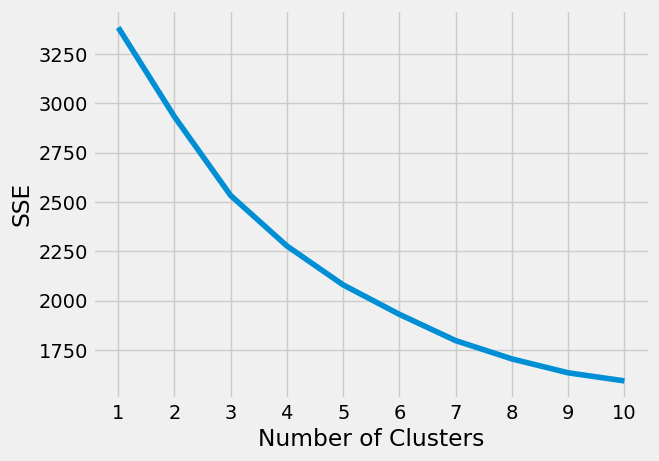

In [353]:
def elbow_fun(data):
    kmeans_kwargs = {
        "init": "random",
        "n_init": 10,
        "max_iter": 300,
        "random_state": 42,
    }

    # A list holds the SSE values for each k
    sse = []
    for k in range(1, 11):
        kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
        kmeans.fit(data)
        sse.append(kmeans.inertia_)

    plt.style.use("fivethirtyeight")
    plt.plot(range(1, 11), sse)
    plt.xticks(range(1, 11))
    plt.xlabel("Number of Clusters")
    plt.ylabel("SSE")
    
    return plt.show()

elbow_fun(word_vectors)

/opt/anaconda3/envs/ls_geo_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning:

The default initialization in TSNE will change from 'random' to 'pca' in 1.2.

/opt/anaconda3/envs/ls_geo_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning:

The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.



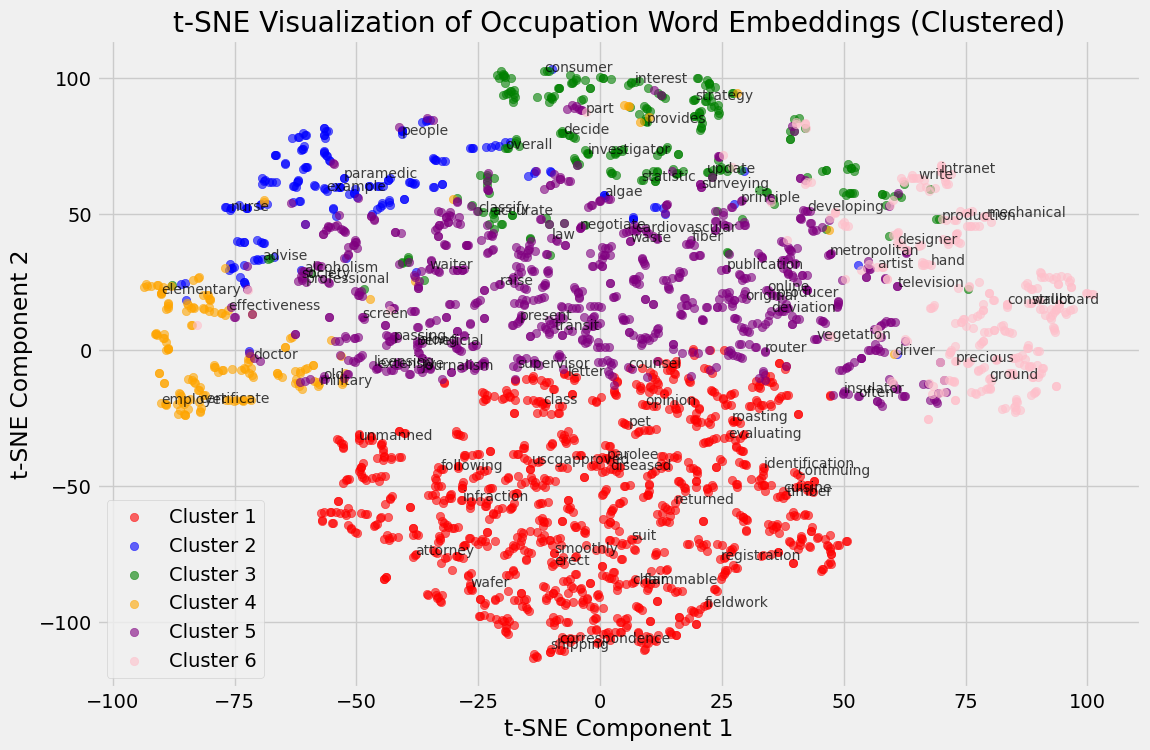

In [354]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from gensim.models import Word2Vec
import random

# Load the trained Word2Vec model
#model = Word2Vec.load("ooh_word2vec.model")

words = list(model.wv.index_to_key)  # Get vocabulary
word_vectors = np.array([model.wv[word] for word in words])  # Get vectors

#tsne
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
word_vectors_2d = tsne.fit_transform(word_vectors)

### kmeans
num_clusters = 6  # Adjust as needed
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(word_vectors)

plt.figure(figsize=(12, 8))

colors = ['red', 'blue', 'green', 'orange', 'purple','pink']#, 'yellow']
for i in range(num_clusters):
    cluster_points = word_vectors_2d[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], alpha=0.6, label=f"Cluster {i+1}")

# Select a subset of words to annotate
num_labels = 100  # Adjust to control clutter
random.seed(42)
selected_indices = random.sample(range(len(words)), min(num_labels, len(words)))

for i in selected_indices:
    plt.annotate(words[i], (word_vectors_2d[i, 0], word_vectors_2d[i, 1]), fontsize=10, alpha=0.75)

plt.title("t-SNE Visualization of Occupation Word Embeddings (Clustered)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()


In [355]:
import plotly.express as px
import plotly.graph_objects as go
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
#from gensim.models import Word2Vec

# Load the trained Word2Vec model
#model = Word2Vec.load("ooh_word2vec.model")

#extract embeddings
words = list(model.wv.index_to_key)  # Get vocabulary
word_vectors = np.array([model.wv[word] for word in words])  # Get vectors

#t-sne
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
word_vectors_2d = tsne.fit_transform(word_vectors)

#clustering
num_clusters = 6  # Adjust based on distinct job categories
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(word_vectors)

# Convert data to a DataFrame for Plotly
import pandas as pd
df = pd.DataFrame({
    'x': word_vectors_2d[:, 0],
    'y': word_vectors_2d[:, 1],
    'word': words,
    'cluster': labels
})

fig = px.scatter(df, x='x', y='y', color=df['cluster'].astype(str),
                 hover_data={'word': True, 'x': False, 'y': False, 'cluster': False},
                 title="t-SNE Visualization of Occupation Embeddings (Interactive)",
                 labels={'cluster': 'Cluster'})

fig.update_traces(marker=dict(size=8, opacity=0.7))  # Improve visibility

# Show the interactive plot
fig.show()


/opt/anaconda3/envs/ls_geo_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning:

The default initialization in TSNE will change from 'random' to 'pca' in 1.2.

/opt/anaconda3/envs/ls_geo_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning:

The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.



In [356]:
import numpy as np
import plotly.express as px
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from gensim.models import Word2Vec

# Load the trained Word2Vec model
#model = Word2Vec.load("ooh_word2vec.model")

# Extract Word Embeddings
words = list(model.wv.index_to_key)  # Get vocabulary
word_vectors = np.array([model.wv[word] for word in words])  # Get vectors

# PCA
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

# Create clusters
num_clusters = 6 # Adjust based on distinct job categories
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(word_vectors)

# Convert data to a DataFrame for Plotly
df = pd.DataFrame({
    'x': word_vectors_2d[:, 0],
    'y': word_vectors_2d[:, 1],
    'word': words,
    'cluster': labels
})

fig = px.scatter(df, x='x', y='y', color=df['cluster'].astype(str),
                 hover_data={'word': True, 'x': False, 'y': False, 'cluster': False},
                 title="PCA Visualization of Occupation Embeddings (Interactive)",
                 labels={'cluster': 'Cluster'})

fig.update_traces(marker=dict(size=8, opacity=0.7))  # Improve visibility

# Show the interactive plot
fig.show()


# Next steps

* save my embeddings
* import them into amazing race analysis and:
    * see if all the occ tokens from AR are in this word2vec model
    * tweek AR tokens as necessary to fit something in the model
* also pull the dataframe into amazing race. Want to associate salary with occupation as a feature in the prediction model
* see if vectorizing our occupations in this way add any predictive power
    * try the occupations separately and try adding the vectors of the two occupations for each player

* explore what some other model, like BERT could do.